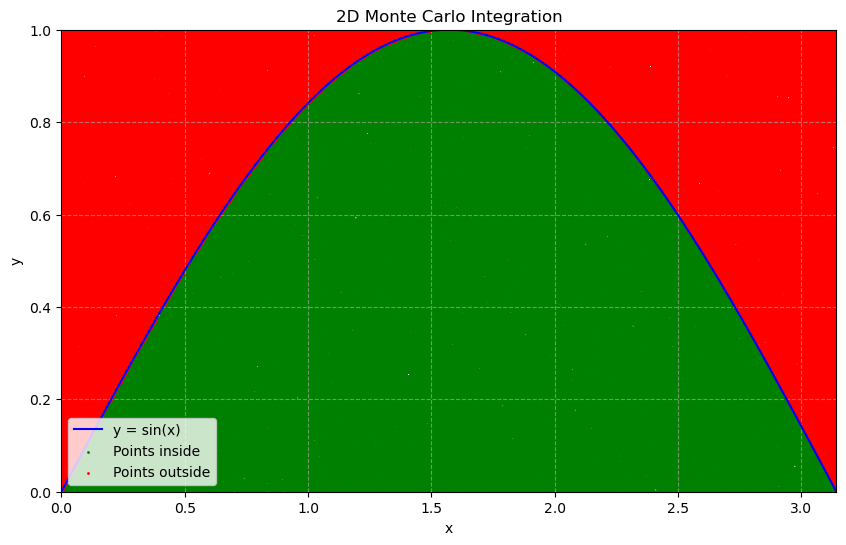

Number of random points: 500000
Actual Integral of sin(x) from 0 to π: 2.0
1D Monte Carlo Integration Result: 2.001100
Error (1D): 0.001100
2D Monte Carlo Integration Result: 1.995571
Error (2D): 0.004429


In [6]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return np.sin(x)

a = 0
b = np.pi

num_points = 500000

x_random_1d = np.random.uniform(a, b, num_points)
y_mean = np.mean(f(x_random_1d))
integral_1d = (b - a) * y_mean

y_min = 0
y_max = 1
area_of_box = (b - a) * (y_max - y_min)

x_random_2d = np.random.uniform(a, b, num_points)
y_random_2d = np.random.uniform(y_min, y_max, num_points)

points_under_curve = np.sum(y_random_2d <= f(x_random_2d))
integral_2d = area_of_box * (points_under_curve / num_points)

actual_value = 2.0

points_inside = y_random_2d <= f(x_random_2d)
x_inside = x_random_2d[points_inside]
y_inside = y_random_2d[points_inside]
x_outside = x_random_2d[~points_inside]
y_outside = y_random_2d[~points_inside]

x_plot = np.linspace(a, b, 1000)
y_plot = f(x_plot)

plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_plot, color='blue', label='y = sin(x)')
plt.scatter(x_inside, y_inside, color='green', s=1, label='Points inside')
plt.scatter(x_outside, y_outside, color='red', s=1, label='Points outside')
plt.title('2D Monte Carlo Integration')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlim(a, b)
plt.ylim(y_min, y_max)
plt.show()

print(f"Number of random points: {num_points}")
print(f"Actual Integral of sin(x) from 0 to \u03C0: {actual_value}")
print(f"1D Monte Carlo Integration Result: {integral_1d:.6f}")
print(f"Error (1D): {abs(integral_1d - actual_value):.6f}")
print(f"2D Monte Carlo Integration Result: {integral_2d:.6f}")
print(f"Error (2D): {abs(integral_2d - actual_value):.6f}")